# Algoritmes voor ontwerp van een nok

In [251]:
import numpy as np
import matplotlib.pyplot as plt

### Toepassing: redraw → wandstrijken (wall ironing)

Onze toepassing is het **redrawen en wandstrijken** (*wall ironing*) van een voorgevormd aluminium napje tot een **dunwandig aluminium cupje voor een waxinelichtje (theelichtje)**. We vertrekken van een reeds gevormde cup (het napje uit de cupper); het **dieptrekken van dat startproduct doen wij dus niet zelf** — dat gebeurt in een voorgaande stap. De nok drijft de ram (stempel) aan die op dat napje twee bewerkingen na elkaar uitvoert:

1. **Redraw** (segment 1, 45°–90°, +5 mm): de ram pakt het voorgevormde napje en trekt het opnieuw na, waardoor de **diameter verkleint**. Het materiaal vloeit over de redraw-radius; de wand wordt nog niet verdund. Dat vraagt een relatief lage, **constante** weerstand — wat overeenkomt met de vlakke ~250 N in deze trap.

2. **Wandstrijken / wall ironing** (segment 2, 90°–180°, +15 mm): de ram duwt de cup door **meerdere opeenvolgende strijkringen**, die elk de wanddikte een stukje verder verdunnen. Doordat er telkens een ring bijkomt, **loopt de kracht lineair op** (250 → 1050 N), met een piek op het einde wanneer de wand volledig is verdund en de bodem wordt aangedrukt.

3. **Terugkeer / strippen** (segment 3, 180°–305°, −20 mm): de ram trekt terug en strippt het cupje van de stempel, met een kleine trekkracht (~300 N), klaar voor de volgende cyclus.

Het eindproduct is dus een licht, goedkoop en voldoende vormvast dunwandig aluminium cupje waarin later was en een lont komen. Omdat het een dun folieproduct is, past de gevraagde kracht (orde 1 kN) goed bij dit type bewerking.

### Specificatie

<a id="specs">Bewegingsspecificatie:</a>

- van 45° tot 90°: heffing van +5 mm.
- van 90° tot 180°: heffing van +15 mm.
- van 180° tot 305°: heffing van -20 mm.

Deze specificatie hoort bij het redrawen en wandstrijken van het voorgevormde napje tot het aluminium waxinelicht-cupje: een korte eerste trap (45°–90°) waarin de ram het napje pakt en op kleinere diameter brengt (de **redraw**, constante kracht), een hoofdslag (90°–180°) waarin de wand door de opeenvolgende strijkringen dun en gelijkmatig wordt getrokken (de **wandstrijkstap**, lineair oplopende kracht) en een terugslag (180°–305°) die de stempel weer vrijtrekt voor de volgende cyclus.

De equivalente massa en demping van de volger zijn 15 kg en 0.055.
De volgende statische krachten moeten gerealiseerd worden:

- van 45° tot 90°: een constante drukkracht van 250 N.
- van 90° tot 180°: een lineair toenemende drukkracht van 250 N tot 1050 N.
- van 180° tot 250°: een constante trekkracht van 300 N.

De beweging moet uitgevoerd zijn in 0.3 seconden.

In [252]:
# specifications:

startangle1 = 45   # degrees
endangle1   = 90   # degrees
theta_seg1  = endangle1 - startangle1  # rotation length for first motion segment
startlift1  =  0
endlift1    =  5
motionlaw1  =  4

startangle2 =  90  # degrees
endangle2   = 180  # degrees
theta_seg2  = endangle2 - startangle2  # rotation length for second segment
startlift2  =  5
endlift2    = 20
motionlaw2  =  4

startangle3 = 180  # degrees
endangle3   = 305  # degrees
theta_seg3  = endangle3 - startangle3  # rotation length for third segment
startlift3  = 20
endlift3    =  0
motionlaw3  =  4

startangleload1 =  45
endangleload1   =  90
startload1      = 250
endload1        = 250

startangleload2 =   90
endangleload2   =  180
startload2      =  250
endload2        = 1050

startangleload3 =  180
endangleload3   =  250
startload3      = -300
endload3        = -300

In [253]:
# Simulation variables of cam:

dtheta = 0.01  # resolution of simulation, in degrees

theta_deg      = np.arange(0,360,dtheta)  # array of cam angles in degrees
theta          = theta_deg*np.pi/180      # array of cam angles in radians
lift           = np.zeros(len(theta))     # lift follower in mm
vel            = np.zeros(len(theta))     # velocity follower in mm/rad
vel_deg        = np.zeros(len(theta))     # velocity follower in mm/degree
acc            = np.zeros(len(theta))     # acceleration follower in mm/rad^2
acc_deg        = np.zeros(len(theta))     # acceleration follower in mm/degree^2
jerk           = np.zeros(len(theta))     # jerk follower in mm/rad^3
jerk_deg       = np.zeros(len(theta))     # jerk follower in mm/degree^3
ext_load       = np.zeros(len(theta))     # external load in N
pressure_angle = np.zeros(len(theta))     # pressure angle in radians

# Cam design parameters, as output of the analysis
base_radius     = []  # base circle radius in mm
follower_radius = []  # follower radius in mm
exc             = []  # excentricity in mm
mass            = []  # equivalent mass in kg
spring_constant = []  # spring constant in N/mm
spring_preload  = []  # spring preload in N
rpm             = []  # rotations per minute of the cam
omega           = []  # angular velocity of the cam in rad/s

# search space of possible R0 values [mm]:
R0_min          =   0
R0_max          = 100
R0_delta        =   0.1
R0_vec          = np.arange(R0_min, R0_max, R0_delta)
# maximum pressure angle corresponding to the evaluated R0s:
alpha_max       = np.zeros_like(R0_vec)

beta_vec        = np.arange(1, 360, 0.1)   # sampling resolution for rotation
rho_min         = np.zeros_like(beta_vec)  # minimal follower radius at each beta

# input parameters of several analysis functions:
beta            = []  # cam angle interval of the segment
startangle      = []  # start angle of the segment in degrees
endangle        = []  # end angle of the segment in degrees
startlift       = []  # start lift of the segment in mm
endlift         = []  # end lift of the segment in mm
startangleload  = []  # start angle of the load in degrees
endangleload    = []  # end angle of the load in degrees
startload       = []  # start load in N
endload         = []  # end load in N
motionlaw       = []  # choice of motion law:
    # 1: dwell,
	  # 2: minimal rms acceleration,
	  # 3: harmonic,
	  # 4: cycloid,
	  # 5: 5th degree poly,
	  # 6: 7th degree poly

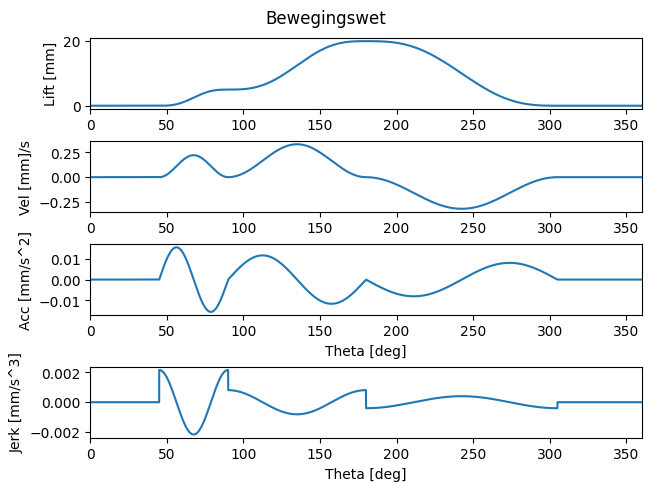

In [254]:
# compute motion functions:

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)
        jerk_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (6 - 12 * x)
        jerk_deg[start_index:end_index] = L / beta**3 * (- 12 )* np.ones_like(x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] = L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2
        jerk_deg[start_index:end_index] = -L / beta**3 * np.sin(np.pi * x) * np.pi**3 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] = L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)
        jerk_deg[start_index:end_index] = 4 * np.pi **2 * L / beta**3 * np.cos(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)
        jerk_deg[start_index:end_index] = L / beta**3 * (360 * x**2 - 360 * x + 60)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)
        jerk_deg[start_index:end_index] = L / beta**3 * (-4200 * x**4 + 8400 * x**3 - 5040 * x**2 + 840 * x)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2
    jerk = jerk_deg*(180/np.pi)**3

    return lift, vel_deg, acc_deg,jerk_deg, vel, acc, jerk

def plotMotionLaw(t,lift,vel,acc, jerk):
    fig1, ax1 = plt.subplots(nrows=4,ncols=1,constrained_layout=True)
    fig1.suptitle("Bewegingswet")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/s")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/s^2]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])

    ax1[3].plot(t, jerk)
    ax1[3].set_ylabel("Jerk [mm/s^3]")
    ax1[3].set_xlabel('Theta [deg]')
    ax1[3].set_xlim([0,360])


# Add all segments to the motion law:

# dwell from 0 to startangle1:
lift, vel_deg, acc_deg, jerk_deg, vel, acc, jerk = addMotionSegment(0,startangle1,0,0,1,dtheta)

# segment 1: rise
lift, vel_deg, acc_deg, jerk_deg, vel, acc, jerk = addMotionSegment(startangle1,endangle1,startlift1,endlift1,motionlaw1,dtheta)

# segment 2: rise
lift, vel_deg, acc_deg, jerk_deg, vel, acc, jerk = addMotionSegment(startangle2,endangle2,startlift2,endlift2,motionlaw2,dtheta)

# segment 3: fall
lift, vel_deg, acc_deg, jerk_deg, vel, acc, jerk = addMotionSegment(startangle3,endangle3,startlift3,endlift3,motionlaw3,dtheta)

# dwell from endangle3 to 360:
lift, vel_deg, acc_deg, jerk_deg, vel, acc, jerk = addMotionSegment(endangle3,360,0,0,1,dtheta)


# Plot the motion law
plotMotionLaw(theta_deg,lift,vel_deg,acc_deg, jerk_deg)

plt.show()

### Keuze van de bewegingswet — afwegingen

De **fundamentele wet** van nokken-ontwerp (Les 5) eist dat de bewegingswet $x(\theta)$ continu is in positie, snelheid én versnelling over de volledige periode $0 \le \theta \le 2\pi$. Dat filtert meteen een aantal wetten weg: constante snelheid, bang-bang, de vólle harmonische en de 3e-orde polynoom hebben aan de aansluiting met een stilstand een versnelling $\ne 0$ of een sprong, en zijn dus ongeschikt tussen twee stilstanden. Wat overblijft als bruikbare *stijgen-stilstand-dalen-stilstand*-wet zijn vooral de **cycloïde**, de **5e-orde** en de **7e-orde** polynoom.

De keuze tussen die drie is een afweging op twee assen:
- **continuïteitsorde / gladheid** $\rightarrow$ hoe minder continu (sprongen in ruk of djerk), hoe meer de beweging de *eigenfrequenties* van de machine aanslaat (trillingen);
- **piek-snelheid en piek-versnelling** $\rightarrow$ een hogere continuïteitsorde geeft gladdere aansluitingen, maar ook hogere pieken, dus een hogere inertiële piekbelasting $m\,a$ en een hoger benodigd motorvermogen.

De **dominante** trade-off is hier de **tolerantie van de toepassing**, niet de kostprijs. De natuurlijke elasticiteit van het contact bepaalt hoeveel bewegingsfout (en trilling) de toepassing verdraagt: een soepel contact (bv. een rubberen stempelkussen) slikt fouten op en verdraagt een minder gladde wet, terwijl een stijf contact (metaal vormen of schrapen) elke afwijking omzet in een krachtpiek en dus een hoge continuïteitsorde vereist. Kostprijs speelt nauwelijks mee: een cosinus of een spline-curve uitfrezen in metaal kost vrijwel evenveel.

**Voor het aluminium waxinelichtcupje** is segment 2 (de wandstrijkende arbeidsslag) een stijf, metaal-op-metaal contact met relatief hoge kracht voor zo'n dun folieproduct. De productkwaliteit is gevoelig voor krachtpieken en trillingen: een kleine afwijking kan al leiden tot wanddikteschommelingen, krassen, plooien of scheuren in het cupje $\rightarrow$ lage tolerantie $\rightarrow$ gladheid (hoge continuïteitsorde) weegt zwaarder dan piek-versnelling. Segment 3 (terugkeer, lage kracht) is vergevingsgezinder.

**Samenvattingstabel van de bewegingswetten** (Les 5; dimensieloos, $s(\tau)$ met $\tau \in [0,1]$):

![Samenvattingstabel van de bewegingswetten](images/motion-law-summary.png)

De dimensionale pieken volgen uit de dimensieloze met $\dfrac{d^nS}{dt^n}\big|_{\max} = \dfrac{L}{\beta^n}\,\omega^n\,(\text{dimensieloze piek})$.

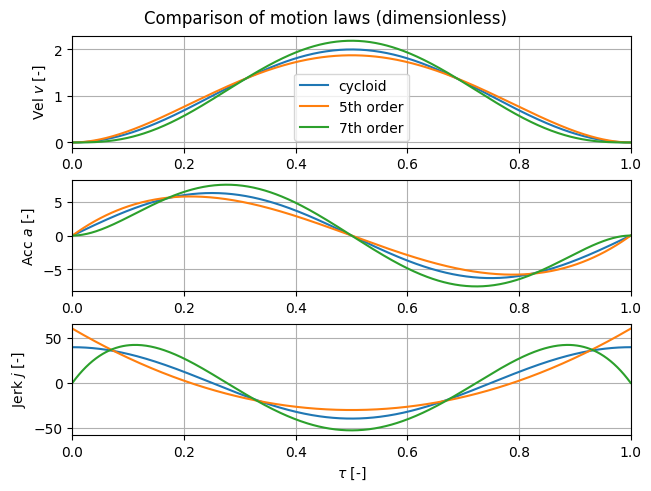

In [255]:
# Comparison of the admissible motion laws (satisfying the fundamental law)
# dimensionless velocity, acceleration and jerk over tau in [0,1]

tau = np.linspace(0, 1, 500)

def motion_law_dimensionless(name, tau):
    if name == 'cycloid':
        v = 1 - np.cos(2*np.pi*tau)
        a = 2*np.pi*np.sin(2*np.pi*tau)
        j = 4*np.pi**2*np.cos(2*np.pi*tau)
    elif name == '5th order':
        v = 30*tau**4 - 60*tau**3 + 30*tau**2
        a = 120*tau**3 - 180*tau**2 + 60*tau
        j = 360*tau**2 - 360*tau + 60
    elif name == '7th order':
        v = -140*tau**6 + 420*tau**5 - 420*tau**4 + 140*tau**3
        a = -840*tau**5 + 2100*tau**4 - 1680*tau**3 + 420*tau**2
        j = -4200*tau**4 + 8400*tau**3 - 5040*tau**2 + 840*tau
    return v, a, j

candidate_laws = ['cycloid', '5th order', '7th order']

fig, ax = plt.subplots(nrows=3, ncols=1, constrained_layout=True)
fig.suptitle('Comparison of motion laws (dimensionless)')
for name in candidate_laws:
    v, a, j = motion_law_dimensionless(name, tau)
    ax[0].plot(tau, v, label=name)
    ax[1].plot(tau, a, label=name)
    ax[2].plot(tau, j, label=name)
ax[0].set_ylabel('Vel $v$ [-]')
ax[1].set_ylabel('Acc $a$ [-]')
ax[2].set_ylabel('Jerk $j$ [-]')
ax[2].set_xlabel(r'$\tau$ [-]')
for k in range(3):
    ax[k].set_xlim([0, 1])
    ax[k].grid()
ax[0].legend()
plt.show()

In [256]:
# Dimensional peak values of the chosen profile (cycloid), per segment
# (Les 5, example 2):  d^nS/dt^n |max = (L / beta^n) * omega^n * (dimensionless peak)

cycletime = 0.3                # s, full revolution (from the specification)
rpm   = 60 / cycletime         # 200 rpm (same speed as used in the spring design)
omega = rpm * 2*np.pi / 60     # rad/s
mass  = 15                     # kg (equivalent mass)

# dimensionless peaks of the cycloid (from the summary table)
v_max, a_max, j_max = 2, 2*np.pi, 4*np.pi**2

segments = [
    ('segment 1', endlift1 - startlift1, theta_seg1),
    ('segment 2', endlift2 - startlift2, theta_seg2),
    ('segment 3', endlift3 - startlift3, theta_seg3),
]

print('%-10s %7s %9s %14s %14s %12s' %
      ('segment', 'L[mm]', 'beta[deg]', 'a_peak[m/s^2]', 'jerk[m/s^3]', 'F_inert[N]'))
for name, L, beta_deg in segments:
    beta = beta_deg * np.pi/180
    L_m  = abs(L) / 1000
    a_pk = L_m / beta**2 * omega**2 * a_max
    j_pk = L_m / beta**3 * omega**3 * j_max
    F_in = mass * a_pk
    print('%-10s %7.1f %9.0f %14.1f %14.0f %12.0f' % (name, L, beta_deg, a_pk, j_pk, F_in))

segment      L[mm] beta[deg]  a_peak[m/s^2]    jerk[m/s^3]   F_inert[N]
segment 1      5.0        45           22.3           3743          335
segment 2     15.0        90           16.8           1404          251
segment 3    -20.0       125           11.6            699          174


In [257]:
# Verification of the cam speed against the specification
T_rev = 60 / rpm                                   # s per revolution
print('Speed %d rpm  ->  %.3f s per full revolution (360 deg).' % (rpm, T_rev))
print('Spec "motion in 0.3 s" read as one full cycle: %s (%.3f s).'
      % ('OK' if abs(T_rev-0.3) < 1e-6 else 'differs', T_rev))
arc = endangle3 - startangle1                      # active arc 45 -> 305 deg
print('For reference: the active arc (%d deg) then takes %.3f s;' % (arc, arc/360*T_rev))
print('               if the spec means the active arc in 0.3 s, %.0f rpm would be needed.'
      % (60/(0.3*360/arc)))

Speed 200 rpm  ->  0.300 s per full revolution (360 deg).
Spec "motion in 0.3 s" read as one full cycle: OK (0.300 s).
For reference: the active arc (260 deg) then takes 0.217 s;
               if the spec means the active arc in 0.3 s, 144 rpm would be needed.


**Besluit per segment.** Alle drie kandidaten (cycloïde, 5e- en 7e-orde) voldoen aan de fundamentele wet. De vergelijking toont de kern van de afweging: de **7e-orde** vertrekt en eindigt met een ruk gelijk aan nul (continue ruk, 4e-orde continuïteit) en slaat dus het minst de machinedynamica aan — ideaal voor een stijve, lage-tolerantie operatie — maar heeft de hoogste piek-versnelling (7,51 t.o.v. 6,28 voor de cycloïde), en dus de grootste inertiële belasting. De **cycloïde** is een goede tussenweg: lagere piek-versnelling en een eindige (zij het discontinue) ruk.

- **Segment 2 (wandstrijken, hoge kracht, stijf, lage tolerantie):** gladheid primeert. Een 7e-orde polynoom is hier te verantwoorden als trillingen of cupkwaliteit kritisch zijn; weegt de inertiële piekbelasting/het motorvermogen zwaarder, dan blijft de cycloïde de betere keuze.
- **Segment 3 (terugkeer, lage kracht, vergevingsgezind):** hier mag de tolerantie ruimer; de cycloïde volstaat ruimschoots en houdt de piek-versnelling laag.

De huidige keuze — cycloïde voor alle segmenten — is dus een verdedigbare, veilige standaard: ze voldoet aan de fundamentele wet, houdt de piek-versnelling beperkt en heeft een eindige ruk. Wil je segment 2 nog gladder, schakel dat segment dan over op de 7e-orde (`motionlaw2 = 6`) en weeg de hogere inertiële piek (zie tabel hierboven) af tegen de winst in trillingsgedrag.

In [258]:
# utility functions for external load

def addLoadSegment(startangleload,endangleload,startload,endload,dtheta):
    assert startangleload - endangleload < 0, 'End angle should be bigger than start angle'
    start_index = int(startangleload/dtheta)
    end_index = int(endangleload/dtheta)
    theta_segment = theta_deg[start_index:end_index]
    ext_load[start_index:end_index] = (endload - startload)/(endangleload - startangleload)*(theta_segment - startangleload) + startload

    return ext_load

def plotExternalLoad(theta_deg,ext_load):
    plt.figure()
    plt.plot(theta_deg, ext_load)
    plt.xlabel('Theta [deg]')
    plt.ylabel('External load [N]')
    plt.xlim([0,360])
    plt.title('External load')

In [259]:
# utility functions for cam profile design (with eccentricity = 0!)

# relate sampled R0 values to pressure angle \alpha:
def Kloomok_Muffley_R0(beta,startlift,endlift,motionlaw):
    global R0_vec, alpha_max
    L0 = startlift
    L1 = endlift
    beta = beta * np.pi / 180
		# 100 samples in dimensionless "arc length" of motion law:
    x = np.arange(0, 1, 0.01)

    for i in range(len(R0_vec)):
        R0 = R0_vec[i]

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        alpha = np.arctan2(vel_ang, R0 + lift)
        alpha_max[i] = np.max(np.abs(alpha)) * 180 / np.pi


# relate given R0 value to samples of curvature radii of motion law:
def Kloomok_Muffley_follower_radius(R0,span,startlift,endlift,motionlaw):
    global beta_vec, rho_min
    L0 = startlift
    L1 = endlift

    for i in range(len(beta_vec)):
        beta = beta_vec[i] * np.pi / 180
        theta = np.linspace(0, beta_vec[i], 100) * np.pi / 180
        x = theta / beta

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_ang = np.zeros_like(x)
            acc_ang = np.zeros_like(x)

        elif motionlaw == 2:  # minimal rms acceleration
            L = L1 - L0
            lift = L * (3 * x**2 - 2 * x**3) + L0
            vel_ang = L / beta * (6 * x - 6 * x**2)
            acc_ang = L / beta**2 * (6 - 12 * x)

        elif motionlaw == 3:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_ang = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_ang = L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2

        elif motionlaw == 4:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_ang = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_ang = 2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)

        elif motionlaw == 5:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_ang = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_ang = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)

        elif motionlaw == 6:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_ang = L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_ang = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

        rho = ((R0 + lift)**2 + vel_ang**2)**(3/2) / ((R0 + lift)**2 + 2 * vel_ang**2 - (R0 + lift) * acc_ang)
        rho_min[i] = np.min(np.abs(rho))

    plt.figure()
    plt.plot(beta_vec, rho_min)
    plt.axvline(x=span, color='b')
    plt.text(span, 0.35*R0, 'span of this segment: (%s)'%(span), color='b', ha='right', va='center', rotation='vertical')
    plt.grid()
    plt.xlabel(r'rotation (degrees)')
    plt.ylabel(r'$\rho$ (mm)')
    plt.xlim([0, 360])
    plt.show()

In [260]:
# utility functions for pressure angle

def calculatePressureAngle(vel,exc,base_radius,follower_radius,lift):
    pressure_angle = np.arctan((vel-exc)/(np.sqrt((base_radius+follower_radius)**2-exc**2)+lift))
    return pressure_angle

def plotPressureAngle(theta_deg,pressure_angle):
    plt.figure()
    plt.plot(theta_deg, pressure_angle*180/np.pi)
    plt.xlabel('rotation [deg]')
    plt.ylabel('Pressure angle [deg]')
    plt.xlim([0,360])

In [261]:
# utility functions for curvature radius

def calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2) #Nortron, Kinematic and dynamics of Machinery eq. 8.31c
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2 # Nortron, Kinematic and dynamics of Machinery eq. 8.34, adapted for vertical follower instead of a horizontal one (--> + pi/2)
    dlambda = -1 + exc/((d+lift)**2 + exc**2) * vel # derivative of lambda with repect to theta
    ddlambda = exc/((d+lift)**2 + exc**2)*acc - 2*exc*(d+lift)*vel**2/((d+lift)**2 + exc**2)**2 # 2nd derivative of lambda with repect to theta

    g = np.sqrt((d+lift)**2 + exc**2)
    dg = vel*(d+lift)/np.sqrt((d+lift)**2 + exc**2) # derivative of g with repect to theta
    ddg = (vel**2  + acc*(d + lift))/np.sqrt((d + lift)**2 + exc**2) - (vel**2*(d + lift)**2)/((d + lift)**2 + exc**2)**(3/2) # 2nd derivative of g with repect to theta

    h = np.sin(lambda_)
    dh = np.cos(lambda_)*dlambda # derivative of h with repect to theta
    ddh = -np.sin(lambda_)*dlambda**2 + np.cos(lambda_)*ddlambda # 2nd derivative of h with repect to theta
    f = np.cos(lambda_)
    df = -np.sin(lambda_)*dlambda #derivative of f with repect to theta
    ddf = -np.cos(lambda_)*dlambda**2 - np.sin(lambda_)*ddlambda # 2nd derivative of f with repect to theta

    dx = df*g + f*dg #derivative of x with repect to theta
    ddx = ddf*g + 2*df*dg + f*ddg # 2nd derivative of x with repect to theta
    dy = dh*g + h*dg # derivative of y with repect to theta
    ddy = ddh*g + 2*dh*dg + h*ddg # 2nd derivative of y with repect to theta

    roc_pitch = -(dx**2 + dy**2)**(3/2) / (dx*ddy - dy*ddx) # general forumula for the radius of curvature
    roc_cam = roc_pitch - follower_radius

    return roc_pitch, roc_cam

def plotRadiusCurvature(theta_deg,roc_pitch,roc_cam):
    inds = np.where(np.abs(np.diff(roc_pitch)/dtheta)<1e3)[0]
    maxi = max(10, max(roc_pitch[inds+1]))
    mini = min(-10, min(roc_pitch[inds+1]))
    plt.figure()
    plt.plot(theta_deg, roc_pitch)
    plt.plot(theta_deg, roc_cam)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Radius of curvature [mm]')
    plt.xlim([0,360])
    plt.ylim([mini,maxi])
    plt.grid()
    plt.title('Radius of curvature')

def plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta,):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2
    xpitch = np.cos(lambda_)*np.sqrt((d+lift)**2 + exc**2)
    ypitch = np.sin(lambda_)*np.sqrt((d+lift)**2 + exc**2)

    xcam = xpitch + follower_radius*np.cos(-theta + pressure_angle + 3*np.pi/2)
    ycam = ypitch + follower_radius*np.sin(-theta + pressure_angle + 3*np.pi/2)

    pitch_curve = np.array([xpitch,ypitch])
    cam_curve = np.array([xcam,ycam])

    x_rolfol_center = exc  # x coordinate of the center of the roller of the follower
    y_rolfol_center = d + lift[0]  # y coordinate of the center of the roller of the follower
    x_rolfol = follower_radius * np.cos(theta) + x_rolfol_center  # x coordinate of the contour of the roller
    y_rolfol = follower_radius * np.sin(theta) + y_rolfol_center  # y coordinate of the contour of the roller

    min_distance_center_roller_to_bore = 2 * follower_radius
    height_bore = follower_radius

    width_block_on_follower = base_radius / 2
    height_block_on_follower = base_radius / 2

    x_boreleft = np.array([exc - 5, exc - 1, exc - 1, exc - 5])
    x_boreright = np.array([exc + 5, exc + 1, exc + 1, exc + 5])
    y_bore = np.array([d + max(lift) + min_distance_center_roller_to_bore] * 2 + [d + max(lift) + min_distance_center_roller_to_bore + height_bore] * 2)
    length_follower = y_bore[-1] - ypitch[0] - follower_radius + 0.2

    x_follower = np.array([x_rolfol_center, x_rolfol_center])
    y_follower = np.array([y_rolfol_center + follower_radius, y_rolfol_center + follower_radius + length_follower])

    x_block_on_follower = np.array([-width_block_on_follower, width_block_on_follower, width_block_on_follower, -width_block_on_follower]) + x_follower[0]
    y_block_on_follower = np.array([0, 0, height_block_on_follower, height_block_on_follower]) + y_follower[1]

    ref_line = np.array([[0, 0], [0, base_radius]])  # line, indicating the reference (= cam position = 0 degrees)

    x_pressangle = np.array([x_rolfol_center + follower_radius * np.sin(pressure_angle[0]), x_rolfol_center - follower_radius * np.sin(pressure_angle[0])])
    y_pressangle = np.array([y_rolfol_center - follower_radius * np.cos(pressure_angle[0]), y_rolfol_center + follower_radius * np.cos(pressure_angle[0])])

    plt.figure()
    plt.fill(cam_curve[0, ::int(1 / dtheta)], cam_curve[1, ::int(1 / dtheta)], 'b')
    plt.fill(x_rolfol[::int(1 / dtheta)], y_rolfol[::int(1 / dtheta)], 'g')
    plt.plot(pitch_curve[0, ::int(1 / dtheta)], pitch_curve[1, ::int(1 / dtheta)], '--r')
    plt.plot(0, 0, 'r+')
    plt.plot(x_pressangle, y_pressangle, 'r--')
    plt.plot(ref_line[0, :], ref_line[1, :], 'r--')
    plt.plot(x_boreleft, y_bore, 'r')
    plt.plot(x_boreright, y_bore, 'r')
    plt.plot(x_follower, y_follower, 'r')
    plt.fill(x_block_on_follower, y_block_on_follower, 'g')

    xlimits = [min(pitch_curve[0, :]), max(pitch_curve[0, :])]
    ylimits = [min(pitch_curve[1, :]), d + max(lift) + follower_radius + length_follower + height_block_on_follower]

    plt.xlim(np.array(xlimits) * 1.2)
    plt.ylim(np.array(ylimits) * 1.05)
    plt.gca().set_aspect('equal')
    plt.grid(True)
    plt.title('Cam contour [mm]')

def calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc):
    omega = rpm*2*np.pi/60
    normalforce_spring = (lift*spring_constant+spring_preload)/np.cos(pressure_angle)
    normalforce_load = ext_load/np.cos(pressure_angle)
    normalforce_acc = mass*acc/1000*(omega**2)/np.cos(pressure_angle)
    normalforce_tot = normalforce_spring + normalforce_load + normalforce_acc
    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = normalforce_tot * np.cos(pressure_angle)

    return normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y

def plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y):
    plt.figure()
    plt.plot(theta_deg,normalforce_tot)
    plt.plot(theta_deg,normalforce_acc,'--r')
    plt.plot(theta_deg,normalforce_load,':g')
    plt.plot(theta_deg,normalforce_spring,'-.m')
    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0,360])
    plt.legend(['total','acc','extload','spring'])
    plt.title('Normal force')

    plt.figure()
    plt.plot(theta_deg,force_x)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force x [N]')
    plt.xlim([0,360])
    plt.title('Force x')

    plt.figure()
    plt.plot(theta_deg,force_y)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force y [N]')
    plt.xlim([0,360])
    plt.title('Force y')

### Ontwerp van minimale steekcirkel $R_0$

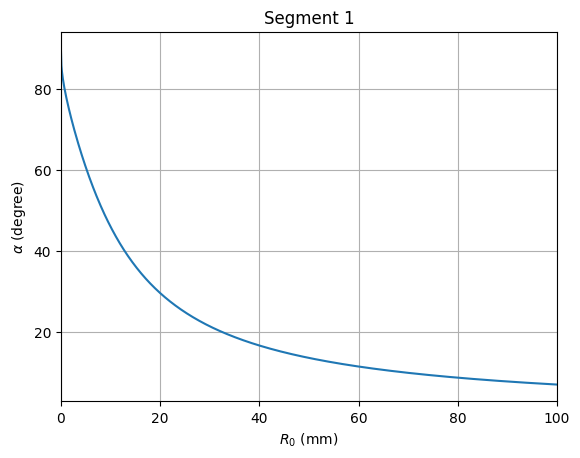

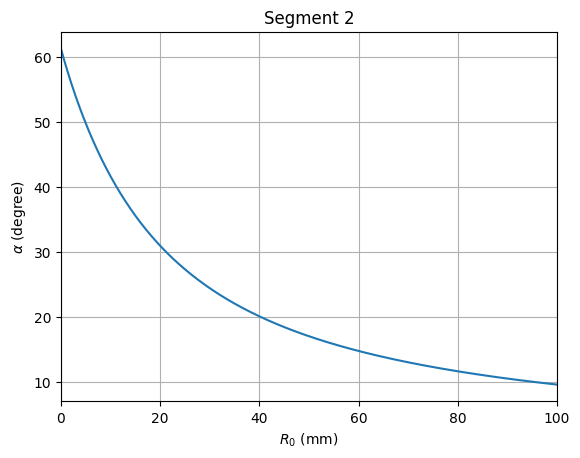

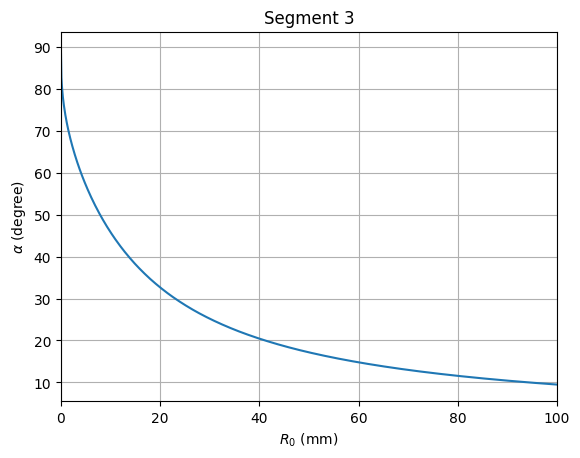

In [262]:
# parameter values for the needed motion segments

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

# The approach was first described by M. Kloomok and R.V. Muffley,
# in Chapter 3 of Mabie, H.H., and Ocvirk, F.W., Mechanisms and Dynamics of Machinery, 1957

# segment 1:
Kloomok_Muffley_R0(theta_seg1,startlift1,endlift1,motionlaw1)

plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 1')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()

# segment 2:
Kloomok_Muffley_R0(theta_seg2,startlift2,endlift2,motionlaw2)

plt.figure()
plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 2')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()

# segment 3:
Kloomok_Muffley_R0(theta_seg3,startlift3,endlift3,motionlaw3)

plt.figure()
plt.plot(R0_vec, alpha_max)
plt.grid()
plt.title('Segment 3')
plt.xlabel('$R_0$ (mm)')
plt.ylabel(r'$\alpha$ (degree)')
plt.xlim([0, 100])
plt.show()

Uit bovenstaande plots besluiten we dat $R_0 = 40\text{ mm}$ een geschikte waarde is.
<br>
(Op basis van de vuistregel dat de maximum drukhoek $a_{\text{max}}$ best onder de 30 graden blijft: alle drie segmenten zitten ruim onder de 30° vanaf $R_0 = 24\text{ mm}$, zodat een compacte waarde van $R_0 = 40\text{ mm}$ een goede keuze is.)

In [263]:
R0 = 40  # pitch radius in mm

Pas op: als je de nokspecificaties aan het <a href="#specs">begin</a> van deze notebook wijzigt, dan kies je misschien voor een andere $R_0$.

### Ontwerp van straal $R_r$ van de volger

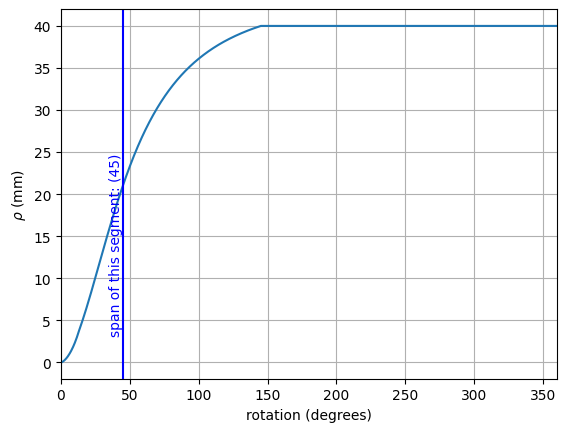

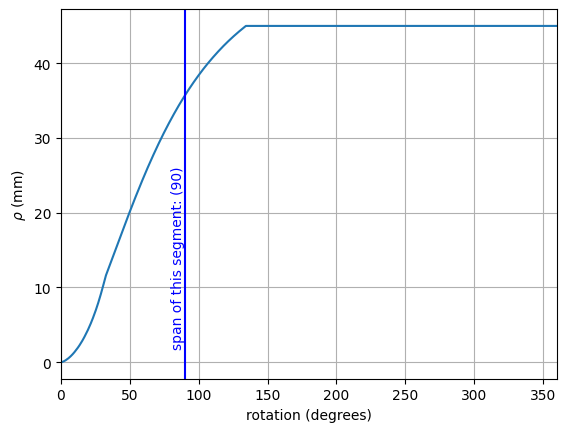

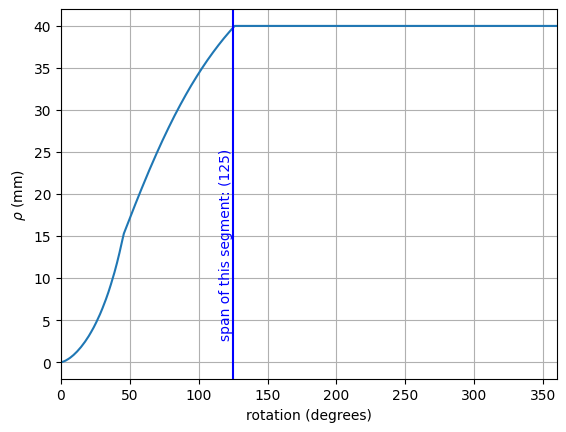

In [264]:
# compute R_r for all segments:

Kloomok_Muffley_follower_radius(R0,theta_seg1,startlift1,endlift1,motionlaw1)
Kloomok_Muffley_follower_radius(R0,theta_seg2,startlift2,endlift2,motionlaw2)
Kloomok_Muffley_follower_radius(R0,theta_seg3,startlift3,endlift3,motionlaw3)

From the plots above, we conclude that the follower radius $R_r$ must be smaller than $21$ mm (segment 1), $36$ mm (segment 2) and $40$ mm (segment 3). Segment 1 is thus the most restrictive. Let's choose $R_r = 10$ mm. And hence, the base radius of the cam is $R_0 - R_r = 30$ mm.

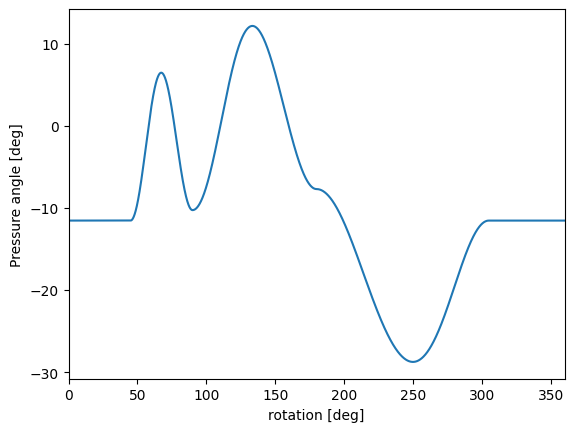

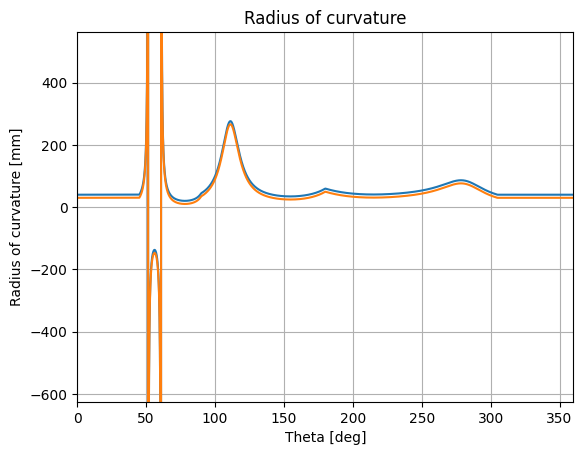

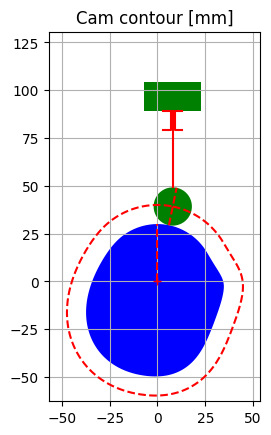

In [265]:
# Kinematics inputs
base_radius     = 30
follower_radius = 10
exc = 8.0  # definitieve keuze; zie 'Keuze van de excentriciteit' onder de krachtenanalyse

# Calculate pressure angle
pressure_angle = calculatePressureAngle(vel,exc,base_radius,follower_radius,lift)
# Plot pressure angle
plotPressureAngle(theta_deg,pressure_angle)

# Calculate radius of curvature
roc_pitch, roc_cam = calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc)

# Plot the radius of curvature
plotRadiusCurvature(theta_deg,roc_pitch,roc_cam)

# Plot the cam contour
plotCamContour(base_radius,follower_radius,exc,theta,lift,pressure_angle,dtheta)

In [266]:
# Undercutting check (Les 6):  rho_min > R_r
# rho_pitch = radius of curvature of the pitch curve. On convex parts (rho_pitch > 0) it
# must not become smaller than the roller radius R_r, otherwise a cusp / undercutting occurs.
finite  = np.abs(np.diff(roc_pitch) / dtheta) < 1e3      # drop the transition spikes
convex  = (roc_pitch[1:] > 0) & finite
rho_min = np.min(roc_pitch[1:][convex])
print('Minimum (convex) pitch-curve radius of curvature rho_min = %.2f mm' % rho_min)
print('Roller radius R_r                                        = %.1f mm' % follower_radius)
print('Undercutting: %s' % ('OK -- rho_min > R_r, no undercutting'
      if rho_min > follower_radius else 'FAIL -- rho_min <= R_r, undercutting!'))

Minimum (convex) pitch-curve radius of curvature rho_min = 20.25 mm
Roller radius R_r                                        = 10.0 mm
Undercutting: OK -- rho_min > R_r, no undercutting


### Optimalisatie van de excentriciteit voor het waxinelichtcupje

Bij de productie van het aluminium waxinelichtcupje drijft de nok een stempel aan. De grootste contactkracht treedt op tijdens de **stijgende beweging** (de *arbeidsslag*): in segment 2 (van 90° tot 180°) loopt de drukkracht op van 250 N tot 1050 N terwijl de stempel de voorgevormde cup door de kalibreer-/wandstrijkmatrijs duwt. Tijdens de **terugkerende beweging** (segment 3, het dalen) is enkel een kleine trekkracht van 300 N nodig om de stempel terug te trekken.

Zoals in de les besproken kan de drukhoek $\alpha$ omlaag door (i) de steekcirkel $R_0$ te vergroten, of (ii) een **excentrische** volger te gebruiken. Een positieve excentriciteit $e$ *verlaagt* de drukhoek tijdens de stijgende beweging (positieve hefsnelheid $f'(\theta)$), maar *verhoogt* ze tijdens de terugkerende beweging (negatieve hefsnelheid), want daar heeft de term $f'(\theta) - e$ in

$$ \alpha = \arctan\!\left( \frac{f'(\theta) - e}{\sqrt{R_0^2 - e^2} + f(\theta)} \right) $$

een ander teken. Net zoals in de les opgemerkt is dat hier gunstig: we drukken de drukhoek — en dus de transversale kracht $T = N\sin(\alpha)$ en de bijhorende wrijving — net daar omlaag waar de contactkracht het grootst is (de stijgende beweging), en aanvaarden een grotere drukhoek tijdens de lichtbelaste terugkeer. De ontwerpregel blijft $|\alpha| < 30°$ voor een translatie-volger.

We werken in twee stappen: eerst bekijken we de evolutie van de drukhoek over de volledige nokrotatie voor enkele excentriciteiten (grove verkenning), daarna zoeken we de optimale waarde.

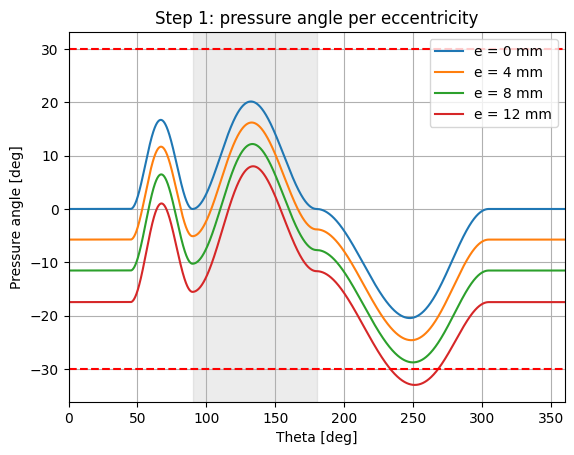

In [267]:
# Step 1: coarse exploration
# pressure angle over the full cam rotation, for a few eccentricities

plt.figure()
for e in [0, 4, 8, 12]:
    alpha = calculatePressureAngle(vel, e, base_radius, follower_radius, lift)
    plt.plot(theta_deg, alpha*180/np.pi, label='e = %d mm' % e)
plt.axhline( 30, color='r', ls='--')
plt.axhline(-30, color='r', ls='--')
plt.axvspan(startangle2, endangle2, color='grey', alpha=0.15)  # rise with the highest deep-drawing force
plt.xlabel('Theta [deg]')
plt.ylabel('Pressure angle [deg]')
plt.xlim([0, 360])
plt.grid()
plt.legend()
plt.title('Step 1: pressure angle per eccentricity')
plt.show()

In de grijze zone (de stijgende beweging, segment 2) zakt de drukhoek duidelijk naarmate de excentriciteit toeneemt, terwijl ze tijdens de terugkerende beweging (segment 3) net stijgt. Voor $e = 12$ mm overschrijdt de terugkeer al de grens van 30°. Het optimum ligt dus ergens tussen 0 en 12 mm. In de tweede stap zoeken we de excentriciteit die de drukhoek tijdens de stijgende beweging minimaliseert zonder elders de 30° te overschrijden.

Optimal eccentricity: 8.80 mm


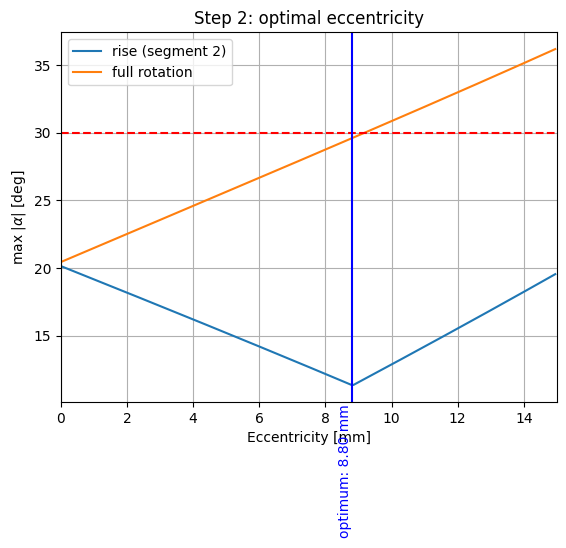

In [268]:
# Step 2: find the optimal eccentricity
# criterion: minimize the maximum pressure angle during the rise (segment 2, the highest
# deep-drawing force), with the design rule |alpha| < 30 deg over the full rotation.

rise = (theta_deg >= startangle2) & (theta_deg < endangle2)  # segment 2

exc_arr     = np.arange(0, 15, 0.05)
alpha_rise  = np.zeros_like(exc_arr)  # max pressure angle during the rise
alpha_total = np.zeros_like(exc_arr)  # max pressure angle over the full rotation
for i in range(len(exc_arr)):
    alpha = calculatePressureAngle(vel, exc_arr[i], base_radius, follower_radius, lift)
    alpha_rise[i]  = np.max(np.abs(alpha[rise])) * 180 / np.pi
    alpha_total[i] = np.max(np.abs(alpha)) * 180 / np.pi

allowed = alpha_total <= 30
exc_opt = exc_arr[allowed][np.argmin(alpha_rise[allowed])]
print('Optimal eccentricity: %.2f mm' % exc_opt)

plt.figure()
plt.plot(exc_arr, alpha_rise,  label='rise (segment 2)')
plt.plot(exc_arr, alpha_total, label='full rotation')
plt.axhline(30, color='r', ls='--')
plt.axvline(exc_opt, color='b')
plt.text(exc_opt, 5, 'optimum: %.2f mm' % exc_opt, color='b', ha='right', va='center', rotation='vertical')
plt.xlabel('Eccentricity [mm]')
plt.ylabel(r'max $|\alpha|$ [deg]')
plt.xlim([0, 15])
plt.grid()
plt.legend()
plt.title('Step 2: optimal eccentricity')
plt.show()

Het optimum is $e \approx 8.8$ mm. Daarmee daalt de maximale drukhoek tijdens de stijgende beweging van ongeveer 20° (centrische volger) tot ongeveer 11°, terwijl de drukhoek over de volledige rotatie net onder de 30° blijft — de terugkerende beweging (segment 3) wordt nu de bepalende factor. Tijdens de zwaarst belaste wandstrijkfase van het waxinelichtcupje wordt de transversale kracht op de stempel zo bijna gehalveerd.

Dit is het optimum volgens het drukhoek-criterium *alleen*. De definitieve excentriciteit kiezen we verderop, na de krachtgebaseerde analyse (stap 3) en de afweging in 'Keuze van de excentriciteit'.

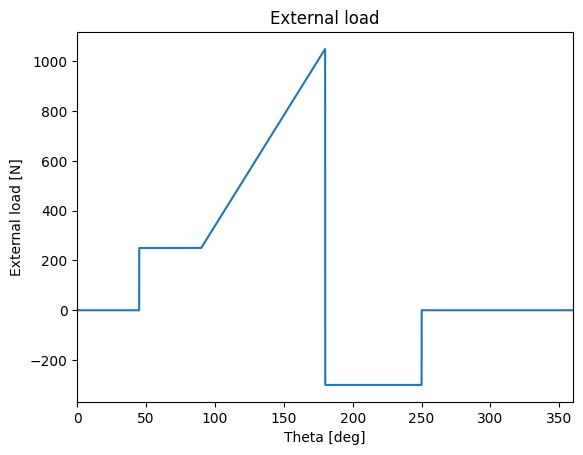

In [269]:
# generate external load

ext_load = addLoadSegment(startangleload1,endangleload1,startload1,endload1,dtheta)
ext_load = addLoadSegment(startangleload2,endangleload2,startload2,endload2,dtheta)
ext_load = addLoadSegment(startangleload3,endangleload3,startload3,endload3,dtheta)

plotExternalLoad(theta_deg,ext_load)

### Veer-dimensionering

De nok kan de volger enkel *duwen*; een veer houdt het contact bij de neergaande beweging (krachtsluiting). De contactkracht is (Les 6):

$$ N = \frac{F_{\text{func}} + F_{v0} + k_v S + m\,\omega^2 S''(\theta)}{\cos(\alpha)}. $$

Om contact te *garanderen* moet $N \ge 0$ over de hele cyclus, dus $F_{v0} + k_v S \ge -F_{\text{func}} - m\,\omega^2 S''$. We volgen de Les 6-strategie: kies eerst de voorspanning $F_{v0}$, en bereken daaruit de minimale veerconstante

$$ k_v = \max_\theta \frac{-F_{v0} - F_{\text{func}} - m\,\omega^2 S''}{S(\theta)}. $$

Dat is een **afweging**: veel voorspanning geeft een hogere basis-contactkracht in de stilstanden (meer wrijving/slijtage) maar een lagere vereiste veerconstante; weinig voorspanning vraagt een stijvere (grotere, duurdere) veer en geeft een hogere piek-contactkracht. We kiezen een matige voorspanning en voegen een veiligheidsmarge toe zodat het contact niet 'net' verloren gaat. (De zwaartekrachtterm $mg\cos\gamma$ wordt hier, net als elders in deze notebook, verwaarloosd.)

Preload F_v0          : 150 N
Minimum spring rate   : 18.67 N/mm
Chosen spring rate    : 22.41 N/mm (margin 20%)
Minimum contact force : 62.9 N  (> 0  =>  force closure OK)
Maximum contact force : 1663.1 N


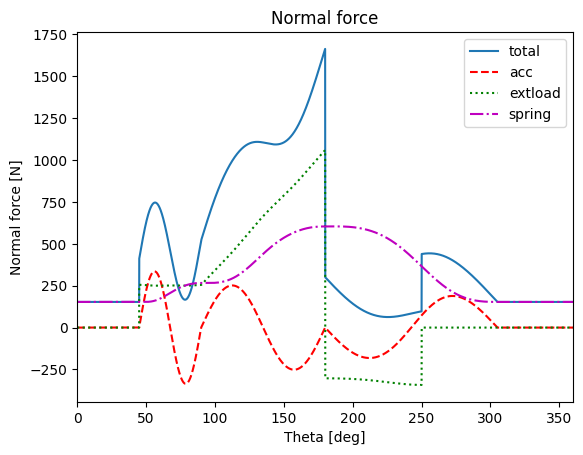

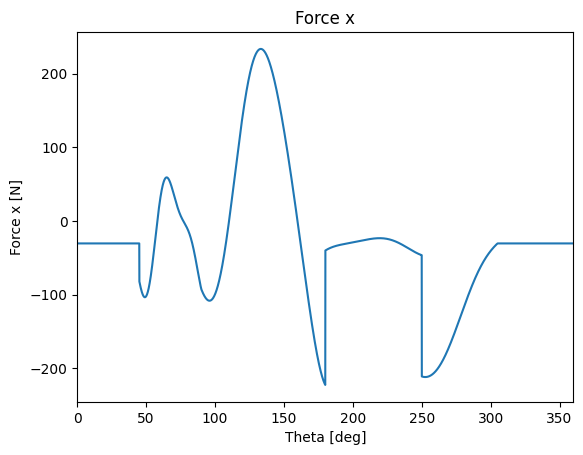

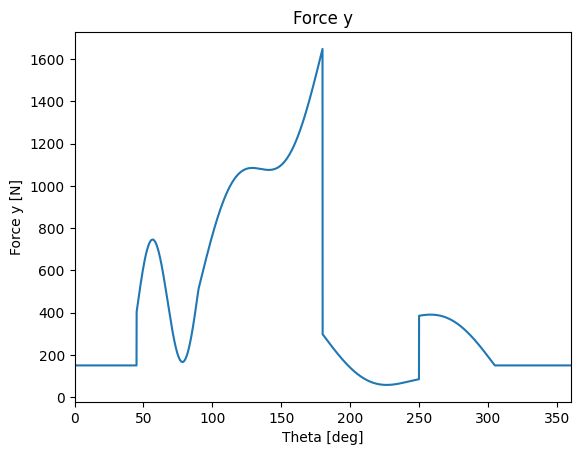

In [270]:
# Spring design (Les 6): choose the preload, then compute the spring rate so that N >= 0

mass  = 15                          # kg (equivalent mass)
rpm   = 200                         # rpm (cycle time 0.3 s)
omega = rpm * 2*np.pi / 60          # rad/s

F_inert = mass * acc/1000 * omega**2   # inertial force m*omega^2*S'' [N]

# 1) choose the preload F_v0
spring_preload = 150.0              # N

# 2) minimum spring rate so that N >= 0:  k_v >= max( -(F_v0 + F_func + F_inert) / S )
mask  = lift > 1e-6
k_min = max(0.0, np.max(-(spring_preload + ext_load + F_inert)[mask] / lift[mask]))

# 3) safety margin so that contact is not lost 'just barely'
safety          = 1.2
spring_constant = k_min * safety
print('Preload F_v0          : %.0f N' % spring_preload)
print('Minimum spring rate   : %.2f N/mm' % k_min)
print('Chosen spring rate    : %.2f N/mm (margin %.0f%%)' % (spring_constant, (safety-1)*100))

# Calculate and plot the forces
[normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y] = calculateForce(
    rpm, lift, spring_constant, spring_preload, pressure_angle, ext_load, mass, acc)
print('Minimum contact force : %.1f N  (> 0  =>  force closure OK)' % np.min(normalforce_tot))
print('Maximum contact force : %.1f N' % np.max(normalforce_tot))
plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y)

We vergelijken twee verschillende doelfuncties:
- de **piek** van $|T|$ over de volledige rotatie — maatgevend voor klemmen, de maximale spanning en het zwaarste slijtage-moment;
- de **wrijvingsarbeid** $\int |T|\,R\, d\theta$ per cyclus (in J, met $R(\theta)=R_0+f(\theta)$ de arm) — het verspilde vermogen $P=T\,R\,\omega$ geïntegreerd over een omwenteling, dus een maat voor de gemiddelde slijtage over de levensduur.

(De veer blijft op de eerder ontworpen waarden; we bekijken enkel het effect van de excentriciteit op de transversale kracht.)

Min. peak |T|      at e = 8.20 mm
Min. friction work at e = 4.00 mm


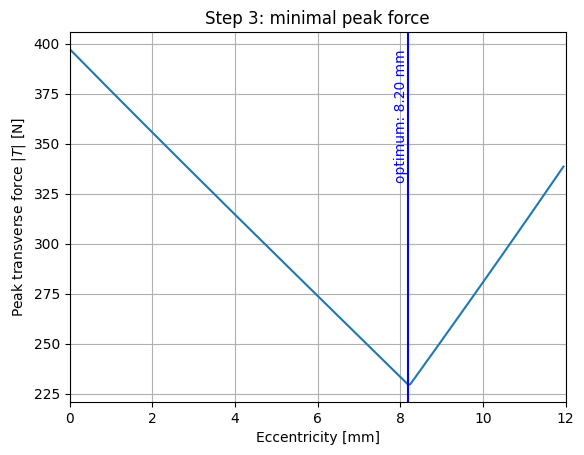

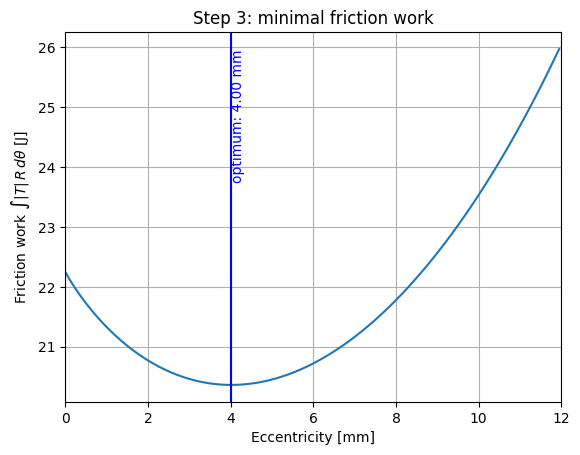

In [271]:
# Step 3: optimize on the transverse force T = N*sin(alpha) = force_x

exc_arr    = np.arange(0, 12, 0.05)
T_peak     = np.zeros_like(exc_arr)   # peak of |T| over the full rotation [N]
W_friction = np.zeros_like(exc_arr)   # friction work per cycle [J]
dtheta_rad = dtheta * np.pi / 180     # angular step in radians
R          = (R0 + lift) / 1000.0     # arm = pitch radius in m

for i in range(len(exc_arr)):
    alpha = calculatePressureAngle(vel, exc_arr[i], base_radius, follower_radius, lift)
    _, _, _, _, force_x, _ = calculateForce(rpm, lift, spring_constant, spring_preload,
                                            alpha, ext_load, mass, acc)
    T_peak[i]     = np.max(np.abs(force_x))
    W_friction[i] = np.sum(np.abs(force_x) * R) * dtheta_rad     # integral |T|*R dtheta [J]

exc_peak     = exc_arr[np.argmin(T_peak)]
exc_friction = exc_arr[np.argmin(W_friction)]
print('Min. peak |T|      at e = %.2f mm' % exc_peak)
print('Min. friction work at e = %.2f mm' % exc_friction)

plt.figure()
plt.plot(exc_arr, T_peak)
plt.axvline(exc_peak, color='b')
plt.text(exc_peak, np.max(T_peak), 'optimum: %.2f mm' % exc_peak,
         color='b', ha='right', va='top', rotation='vertical')
plt.xlabel('Eccentricity [mm]')
plt.ylabel('Peak transverse force $|T|$ [N]')
plt.xlim([0, 12])
plt.grid()
plt.title('Step 3: minimal peak force')
plt.show()

plt.figure()
plt.plot(exc_arr, W_friction)
plt.axvline(exc_friction, color='b')
plt.text(exc_friction, np.max(W_friction), 'optimum: %.2f mm' % exc_friction,
         color='b', ha='left', va='top', rotation='vertical')
plt.xlabel('Eccentricity [mm]')
plt.ylabel(r'Friction work $\int |T|\,R\, d\theta$ [J]')
plt.xlim([0, 12])
plt.grid()
plt.title('Step 3: minimal friction work')
plt.show()

De twee doelfuncties geven een **verschillend** optimum (zie de geprinte waarden hierboven):
- de **piek** van $|T|$ is minimaal rond $e \approx 8.2$ mm;
- de **wrijvingsarbeid** $\int |T|\,R\, d\theta$ is minimaal rond $e \approx 4$ mm.

Ze vallen dus niet samen. Excentriciteit *herverdeelt* de transversale kracht: ze knipt de hoge piek tijdens de stijgende beweging weg, maar verhoogt $T$ over het bredere terugkeer-traject. De piek-doelfunctie kijkt enkel naar het zwaarste ogenblik en blijft daardoor verbeteren tot $e \approx 8.2$ mm; de wrijvingsarbeid telt de volledige rotatie op en bereikt zijn minimum vroeger. Opvallend: na het dimensioneren van de veer ligt het piek-optimum vlak bij het drukhoek-optimum uit stap 2 ($e \approx 8.8$ mm) — beide criteria wijzen nu naar dezelfde zone.

### Keuze van de excentriciteit

We kiezen **$e = 8$ mm**. Na de veerdimensionering wijzen twee onafhankelijke criteria naar dezelfde zone: het is (nagenoeg) de excentriciteit die de **piek-transversale kracht** minimaliseert (stap 3, $\approx 8.2$ mm) én ze valt vlak bij het minimum van de **drukhoek** in de stijgende beweging (stap 2, $\approx 8.8$ mm). De drukhoek blijft over de volledige rotatie onder de 30° ($\approx 28.8°$, met wat marge).

Dit is de logische keuze voor het waxinelichtcupje: die toepassing faalt in de eerste plaats door een te grote *zijbelasting* op de stempel tijdens de zware wandstrijkslag — klemmen, galling, krassen, een gescheurd of afgekeurd cupje of matrijsschade. Dat zijn **piek**-gedreven faalvormen. Bij $e = 8$ mm daalt de piek-transversale kracht met ~40 % t.o.v. een centrische volger (zie de vergelijking hieronder), terwijl de totale wrijvingsarbeid nagenoeg gelijk blijft.

Waarom je toch een andere waarde zou kunnen kiezen:

- **$e \approx 4$ mm** (minimale wrijvingsarbeid): kies dit als de levensduur primeert — wrijvingsverlies, warmte en geleidelijke slijtage over de miljoenen cycli van cupjesproductie. Nadeel: een hogere piek-zijkracht, dus meer risico op klemmen/afkeur tijdens de arbeidsslag.
- **centrisch ($e = 0$)**: de eenvoudigste en goedkoopste geometrie, symmetrisch gedrag. Nadeel: de hoogste piek-zijkracht.

In [272]:
# Comparison: peak transverse force and friction work -- chosen e vs centric
dtheta_rad = dtheta * np.pi / 180
print('%-18s %12s %20s' % ('', 'peak |T| [N]', 'friction work [J]'))
for e_cmp, name in [(0.0, 'centric (e=0)'), (exc, 'chosen (e=%.1f)' % exc)]:
    alpha = calculatePressureAngle(vel, e_cmp, base_radius, follower_radius, lift)
    _, _, _, _, fx, _ = calculateForce(rpm, lift, spring_constant, spring_preload,
                                       alpha, ext_load, mass, acc)
    T = np.abs(fx)                                   # transverse force |T| = |N sin(alpha)|
    R = (R0 + lift) / 1000.0                          # arm = pitch radius in m
    W = np.sum(T * R) * dtheta_rad                    # friction / transmission work per cycle [J]
    print('%-18s %12.1f %20.2f' % (name, np.max(T), W))

                   peak |T| [N]    friction work [J]
centric (e=0)             397.3                22.25
chosen (e=8.0)            233.5                21.78


### Dynamische analyse: koppel, motorvermogen en vliegwiel

Het koppel op de nokas is gelijk aan het overgedragen vermogen gedeeld door $\omega$. Het vermogen dat de nok aan de volger levert is de **axiale** contactkracht maal de volgersnelheid, $P = (N\cos\alpha)\,\dot S$, zodat

$$ M(\theta) = N(\theta)\,\cos(\alpha(\theta))\,\frac{dS}{d\theta}. $$

Voor een centrische volger ($e=0$) valt dit samen met de Les 6-vorm $P = N\,\sin(\alpha)\,R\,\omega$; bij excentriciteit is dit de algemene, energetisch correcte uitdrukking. De axiale kracht $N\cos\alpha$ is net het verticaal krachtevenwicht ($F_{func}+F_{v0}+k_vS+m\,\omega^2 S''$), zodat de piek-inertiekracht uit de bewegingswet-analyse hier rechtstreeks in doorwerkt. Het motorkoppel is bij benadering constant en gelijk aan het gemiddelde $M_{av}$; het gemiddelde motorvermogen is $P = M_{av}\,\omega$.

De schommeling van $M(\theta)$ rond $M_{av}$ versnelt en vertraagt de nokas; een **vliegwiel** vlakt die af. Volgens Les 4 is het maximale arbeids-surplus $A_{max} = \max_\theta A(\theta) - \min_\theta A(\theta)$ met $A(\theta) = \int_0^\theta (M_{av} - M)\,d\theta$, en is de benodigde (totale) astraagheid voor een gewenste fluctuatiecoëfficiënt $K$:

$$ I = \frac{A_{max}}{K\,\omega_{av}^2}. $$

Mean torque  M_av     = 2.34 Nm
Peak torque  |M|max   = 20.63 Nm
Mean power   P_motor  = 49.0 W


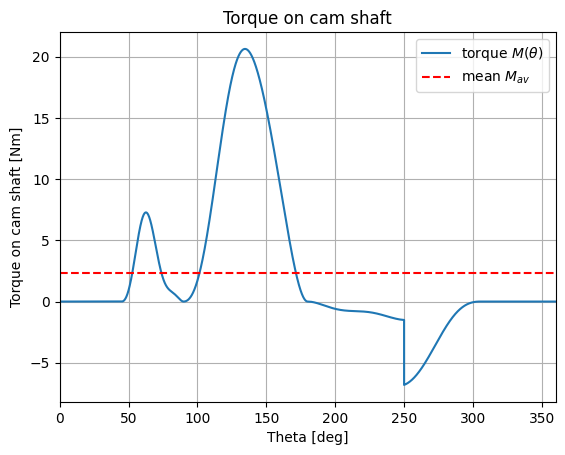

In [273]:
# Torque on the cam shaft and mean motor power

M_load = normalforce_tot * np.cos(pressure_angle) * (vel / 1000.0)   # torque on cam shaft [Nm]  (= N*cos(alpha)*dS/dtheta)

M_av    = np.mean(M_load)                                       # mean torque = motor torque
P_motor = M_av * omega                                          # mean motor power [W]

print('Mean torque  M_av     = %.2f Nm' % M_av)
print('Peak torque  |M|max   = %.2f Nm' % np.max(np.abs(M_load)))
print('Mean power   P_motor  = %.1f W'  % P_motor)

plt.figure()
plt.plot(theta_deg, M_load, label=r'torque $M(\theta)$')
plt.axhline(M_av, color='r', ls='--', label=r'mean $M_{av}$')
plt.xlabel('Theta [deg]')
plt.ylabel('Torque on cam shaft [Nm]')
plt.xlim([0, 360])
plt.grid()
plt.legend()
plt.title('Torque on cam shaft')
plt.show()

Maximum work surplus  A_max = 13.40 J
Desired fluctuation   K     = 5 %
Required inertia      I     = 0.6112 kg*m^2
Steel disc: d = 400 mm  ->  thickness t = 31.0 mm,  mass = 30.6 kg


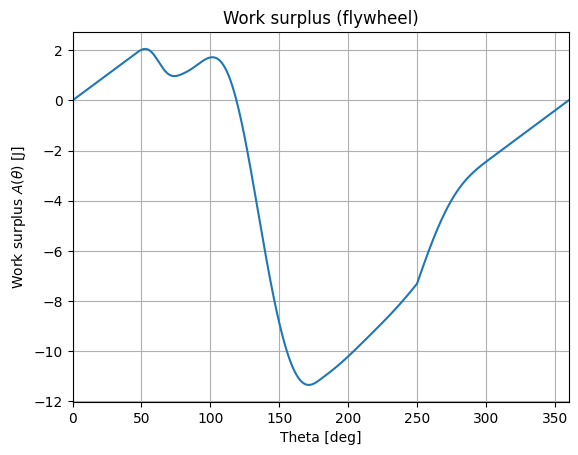

In [274]:
# Flywheel design (Les 4)

dtheta_rad = dtheta * np.pi / 180
A_theta    = np.cumsum(M_av - M_load) * dtheta_rad     # work surplus A(theta) [J]
A_max      = np.max(A_theta) - np.min(A_theta)         # maximum work fluctuation [J]

K          = 0.05            # desired coefficient of fluctuation (choice, here 5%)
omega_av   = omega
I_flywheel = A_max / (K * omega_av**2)                 # required shaft inertia [kg*m^2]

print('Maximum work surplus  A_max = %.2f J' % A_max)
print('Desired fluctuation   K     = %.0f %%' % (K*100))
print('Required inertia      I     = %.4f kg*m^2' % I_flywheel)

# Design as a steel disc:  I = pi*rho*d^4*t/32  ->  t = 32*I/(pi*rho*d^4)
rho = 7850          # kg/m^3 (steel)
d   = 0.40          # m, diameter limited by the available space (choice)
t   = 32 * I_flywheel / (np.pi * rho * d**4)
m_fly = rho * np.pi * (d/2)**2 * t
print('Steel disc: d = %.0f mm  ->  thickness t = %.1f mm,  mass = %.1f kg' % (d*1000, t*1000, m_fly))

plt.figure()
plt.plot(theta_deg, A_theta)
plt.xlabel('Theta [deg]')
plt.ylabel(r'Work surplus $A(\theta)$ [J]')
plt.xlim([0, 360])
plt.grid()
plt.title('Work surplus (flywheel)')
plt.show()

Het gemiddelde motorvermogen is bescheiden (orde 50 W), maar het koppel schommelt sterk rond dat gemiddelde (piek ~21 N·m): de nok-belasting is dus erg "piekerig". Daardoor is de benodigde vliegwieltraagheid relatief groot. De keuzes $K$ (toegelaten snelheidsfluctuatie) en de diameter $d$ (inbouwruimte) bepalen samen de massa: een strakkere $K$ of een kleinere $d$ geeft een zwaarder/dikker vliegwiel ($I \propto d^4 t$). Een **velg-vliegwiel** in plaats van een volle schijf levert dezelfde traagheid met aanzienlijk minder materiaal (Les 4), wat hier de logische volgende stap is als de ~31 mm dikke, ~31 kg schijf te zwaar uitvalt.

(De getallen volgen uit de gekozen $e = 8$ mm en de veerinstelling hierboven; pas je die aan, dan veranderen koppel, vermogen en vliegwiel mee.)

---

## Eind-checklist en samenvatting van het ontwerp

**Definitieve ontwerpparameters**

| parameter | waarde |
|---|---|
| bewegingswet (alle segmenten) | cycloïde |
| steekcirkel $R_0$ | 40 mm |
| rolstraal $R_r$ | 10 mm |
| basiscirkel $R_b = R_0 - R_r$ | 30 mm |
| excentriciteit $e$ | 8 mm |
| voorspanning veer $F_{v0}$ | 150 N |
| veerconstante $k_v$ | 22,4 N/mm |
| toerental | 200 rpm (0,3 s/omwenteling) |

**Controles**

- [x] Fundamentele wet: positie, snelheid en versnelling continu (cycloïde, $a=0$ aan elke aansluiting).
- [x] Drukhoek $|\alpha|_{\max} \approx 28{,}8° < 30°$ (vuistregel translatie-volger).
- [x] Ondersnijding: $\rho_{\min} = 20{,}3\text{ mm} > R_r = 10\text{ mm}$.
- [x] Krachtsluiting: minimale contactkracht $\approx 63\text{ N} > 0$ over de hele cyclus.
- [x] Toerental klopt met de spec (volledige cyclus in 0,3 s).

**Afgewerkte ontwerpstappen**

- [x] Bewegingswet gekozen met trade-off-analyse (Les 5).
- [x] Steekcirkel $R_0$ bepaald via de drukhoek (Kloomok–Muffley).
- [x] Rolstraal $R_r$ bepaald via de kromtestraal / ondersnijding.
- [x] Drukhoek berekend en gecontroleerd ($<30°$).
- [x] Excentriciteit geoptimaliseerd (drukhoek én transversale kracht) en gekozen ($e=8$ mm).
- [x] Nokprofiel (steekkromme + contour) afgeleid.
- [x] Veer gedimensioneerd volgens Les 6 ($N \ge 0$).
- [x] Krachten berekend (contactkracht, transversale kracht).
- [x] Koppel op de nokas en gemiddeld motorvermogen ($\approx 49$ W, piek $\approx 21$ N·m).
- [x] Vliegwiel gedimensioneerd (Les 4): $I \approx 0{,}61\text{ kg·m}^2$, stalen schijf Ø400 mm $\approx$ 31 mm / $\approx$ 31 kg.

**Nog te overwegen (optioneel / afwerking)**

- [ ] Velg-vliegwiel uitwerken als de schijf van ~31 kg te zwaar/groot is (zelfde $I$, minder materiaal).
- [ ] Zwaartekracht $mg\cos\gamma$ en wrijving $\mu R$ toevoegen aan het krachtmodel indien de toepassing dat vereist (nu verwaarloosd).
- [ ] Segment 2 eventueel op een 7e-orde bewegingswet zetten als trillingen / cupkwaliteit kritischer blijken dan de inertiële piekbelasting.
- [ ] Concrete veer en motor uit een catalogus selecteren op basis van bovenstaande waarden.